# IMDB Dataset - Download and Exploration

This notebook explores the IMDB sentiment-analysis dataset befre wew use it to fine-tune BERT.

Goals:
1. Download the IMDB dataset
2. Understand its structure
3. Inspect examples
4. Check class distribution
5. Analyze review lengths
6. Identify potential data issues


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datasets
from datasets import load_dataset

import huggingface_hub


In [2]:
print("datasets:", datasets.__version__)
print("huggingface_hub:", huggingface_hub.__version__)


datasets: 5.0.1
huggingface_hub: 1.27.0


In [3]:
dataset = load_dataset("stanfordnlp/IMDB")

In [4]:
## The Shape of train and test dataset
print("Training set Shape: ",dataset["train"].shape)
print("Test set Shape: ",dataset["test"].shape)

## Lets have a look at one example from the training set
print("Example from the training set: ",dataset["train"][0].keys())

Training set Shape:  (25000, 2)
Test set Shape:  (25000, 2)
Example from the training set:  dict_keys(['text', 'label'])


In [5]:
## Lets look at some positive and negative examples from the training set

## Positive dataset
positive_exp = dataset["train"].filter(lambda example: example["label"]==1)
display("positive example: ", positive_exp[0])

## Negative dataset
negative_exp = dataset["train"].filter(lambda example: example["label"]==0)
display("negative example: ", negative_exp[0])

## Also lets check the class distributiion in the training set
from collections import Counter
train_labels = dataset["train"]["label"]
label_counts = Counter(train_labels)
print("Class distribution in the training set: ", label_counts)

'positive example: '

{'text': 'Zentropa has much in common with The Third Man, another noir-like film set among the rubble of postwar Europe. Like TTM, there is much inventive camera work. There is an innocent American who gets emotionally involved with a woman he doesn\'t really understand, and whose naivety is all the more striking in contrast with the natives.<br /><br />But I\'d have to say that The Third Man has a more well-crafted storyline. Zentropa is a bit disjointed in this respect. Perhaps this is intentional: it is presented as a dream/nightmare, and making it too coherent would spoil the effect. <br /><br />This movie is unrelentingly grim--"noir" in more than one sense; one never sees the sun shine. Grim, but intriguing, and frightening.',
 'label': 1}

'negative example: '

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

Class distribution in the training set:  Counter({0: 12500, 1: 12500})


(25000, 2)


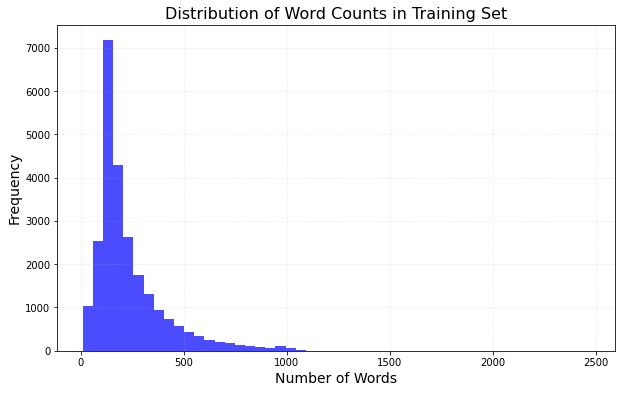

In [14]:
## Convert part of the dataset to pandas
train_df = dataset["train"].to_pandas()
print(train_df.shape)

train_df["word_count"] = train_df["text"].apply(lambda x: len(x.split()))

## Plot to review the lengths
plt.figure(figsize=(10,6))
plt.hist(train_df["word_count"], bins=50, color = "blue", alpha=0.7)
plt.title("Distribution of Word Counts in Training Set", fontsize=16)
plt.xlabel("Number of Words", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.grid(True, alpha = 0.2, linestyle = "--")
plt.show()


In [18]:
## Lets check the longest review as well!
longest_df = train_df.nlargest(5, "word_count")[["text", "label","word_count"]]
smallest_df = train_df.nsmallest(5, "word_count")[["text", "label", "word_count"]]
display("longest_df: ", longest_df)
display("smallest_df: ", smallest_df)

## Check for duplicates and missing values
duplicates = train_df.duplicated().sum()
missing_values = train_df.isnull().sum().sum()
print("Number of duplicate rows in the training set:", duplicates)
print("Number of missing values in the training set:", missing_values)

'longest_df: '

,text,label,word_count
13756,Match 1: Tag Team Table Match Bubba Ray and Sp...,1,2470
22551,Titanic directed by James Cameron presents a f...,1,1839
16948,**Attention Spoilers**<br /><br />First of all...,1,1830
16487,By now you've probably heard a bit about the n...,1,1723
15085,*!!- SPOILERS - !!*<br /><br />Before I begin ...,1,1601


'smallest_df: '

,text,label,word_count
2404,I wouldn't rent this one even on dollar rental...,0,10
10925,This movie is terrible but it has some good ef...,0,10
373,You'd better choose Paul Verhoeven's even if y...,0,11
12114,Ming The Merciless does a little Bardwork and ...,0,12
17069,Adrian Pasdar is excellent is this film. He ma...,1,12


Number of duplicate rows in the training set: 96
Number of missing values in the training set: 0
